In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

#解决画图中文乱码问题
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid",font='SimHei')

#读取数据
df=pd.read_csv('深圳二手房.csv',encoding='utf-8')

#清理无用的列，保持数据整洁
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print("原始数据读取成功！前3行预览：")
print(df.head(3))

原始数据读取成功！前3行预览：
    district  roomnum  hall  AREA C_floor  floor_num  school  subway  \
0  guangming        3     2  89.0     low         36       0       0   
1  guangming        3     2  82.5     low         16       1       0   
2  guangming        3     2  82.5     low         16       1       0   

   per_price  
0     7.1910  
1     7.1515  
2     7.1515  


In [23]:
df_clean = df.copy()
print(f"[清洗前] 原始数据总行数：{df_clean.shape[0]}")

#统计并处理缺失值
missing_summary = df_clean.isnull().sum()
print("检查各列缺失值情况：\n",missing_summary)
df_clean.dropna(subset=['AREA','per_price'], inplace=True)

#统一字段数据类型
for col in ['AREA','per_price','floor_num','roomnum','hall']:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

#处理极端异常值
before_outliers = df_clean.shape[0]
df_clean = df_clean[(df_clean['AREA']>10) & (df_clean['per_price'] > 0)]
print(f"过滤极端异常值：清除了{before_outliers - df_clean.shape[0]} 行离群数据")

#去除重复房源
before_duplicates = df_clean.shape[0]
df_clean.drop_duplicates(inplace=True)
print(f"去除重复项：清除了 {before_duplicates - df_clean.shape[0]} 行重复数据")

#衍生变量特征工程 计算总价
df_clean['total_price']=df_clean['AREA'] * df_clean['per_price']

print(f"[清洗后] 最终可用健康数据总行数: {df_clean.shape[0]}")

[清洗前] 原始数据总行数：15263
检查各列缺失值情况：
 district     0
roomnum      0
hall         0
AREA         0
C_floor      0
floor_num    0
school       0
subway       0
per_price    0
dtype: int64
过滤极端异常值：清除了0 行离群数据
去除重复项：清除了 1805 行重复数据
[清洗后] 最终可用健康数据总行数: 13458


C:\Users\38113\AppData\Local\Temp\ipykernel_25760\1630032830.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='district',data=df_clean,order=df_clean['district'].value_counts().index,ax=axes[0,0],palette='Blues_r')
C:\Users\38113\AppData\Local\Temp\ipykernel_25760\1630032830.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='per_price', y='district', data=district_price, ax=axes[1, 0], palette='Reds_r')


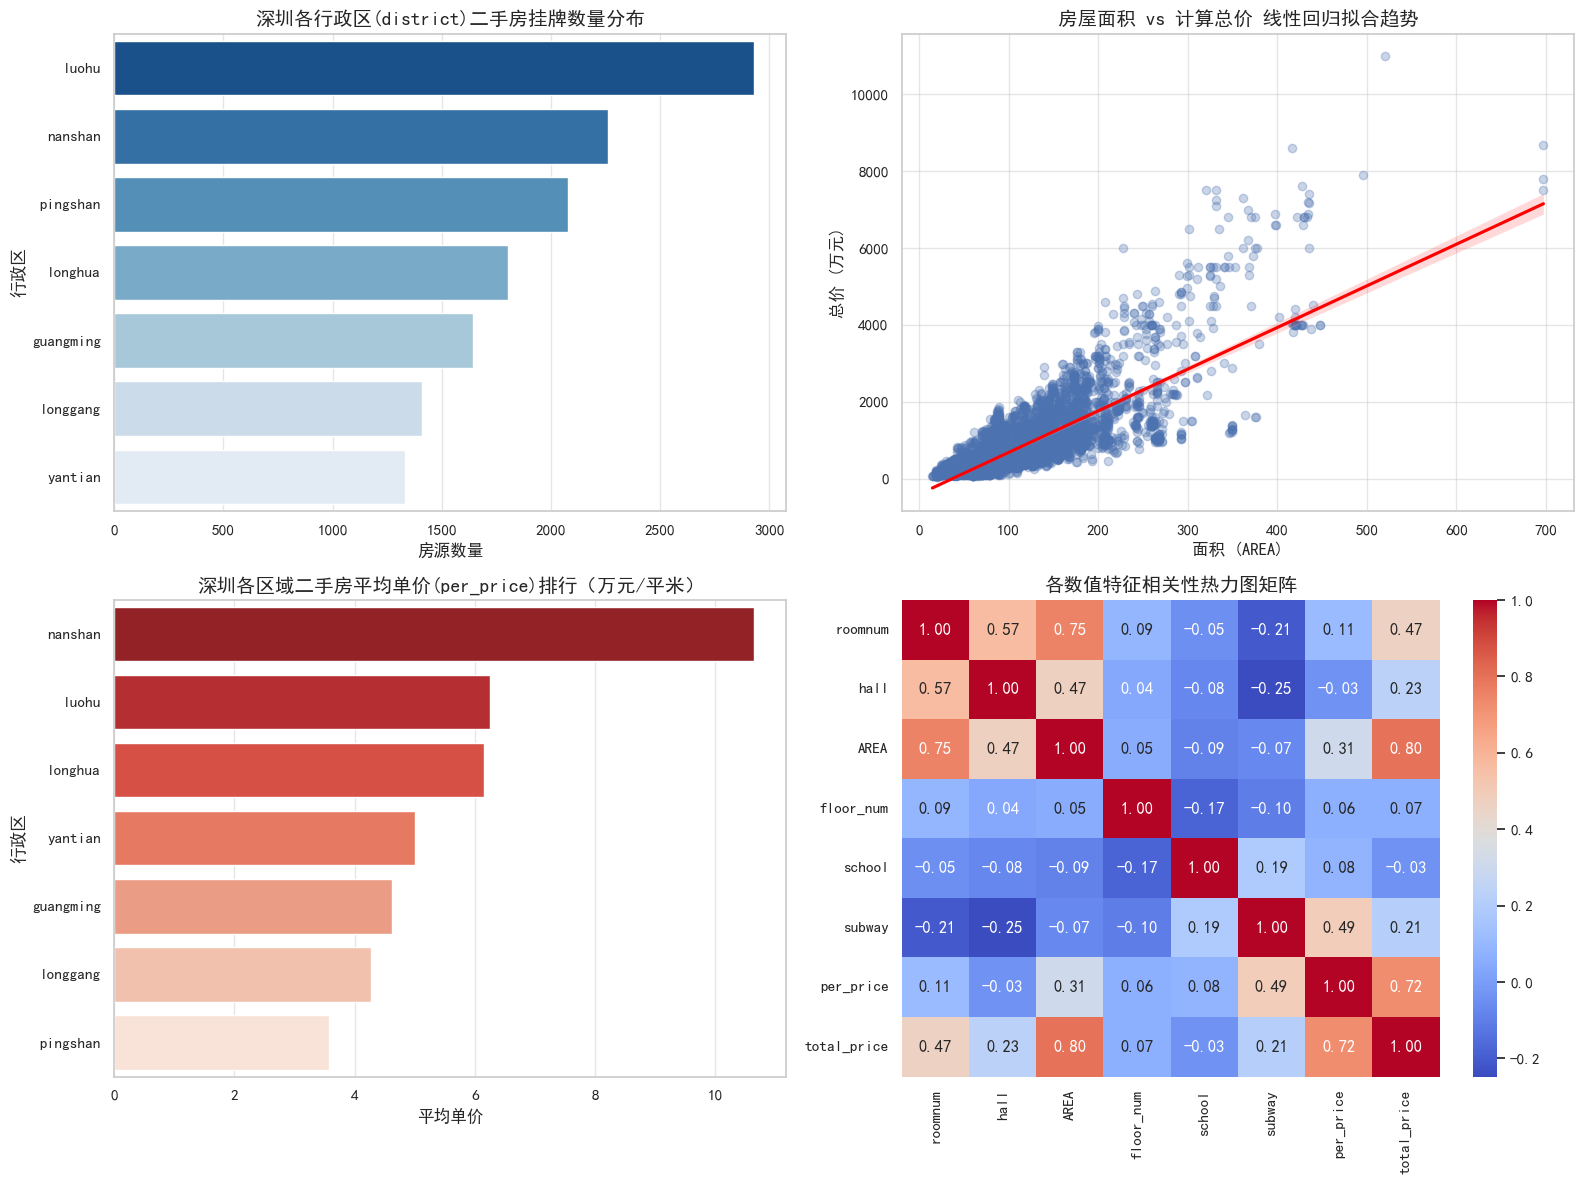

In [26]:
fig,axes = plt.subplots(2,2,figsize=(16,12))

# 【图一】：各行政区挂牌数量分布
sns.countplot(y='district',data=df_clean,order=df_clean['district'].value_counts().index,ax=axes[0,0],palette='Blues_r')
axes[0, 0].set_title('深圳各行政区(district)二手房挂牌数量分布', fontsize=14)
axes[0, 0].set_xlabel('房源数量')
axes[0, 0].set_ylabel('行政区')

# 【图二】：面积vs总价 线性回归拟合图
sns.regplot(x='AREA', y='total_price', data=df_clean, ax=axes[0, 1], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[0, 1].set_title('房屋面积 vs 计算总价 线性回归拟合趋势', fontsize=14)
axes[0, 1].set_xlabel('面积 (AREA)')
axes[0, 1].set_ylabel('总价 (万元)')

# 【图三】：各行政区平均单价排行
district_price = df_clean.groupby('district')['per_price'].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='per_price', y='district', data=district_price, ax=axes[1, 0], palette='Reds_r')
axes[1, 0].set_title('深圳各区域二手房平均单价(per_price)排行（万元/平米）', fontsize=14)
axes[1, 0].set_xlabel('平均单价')
axes[1, 0].set_ylabel('行政区')

# 【图四】：各数值特征相关性热力图
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
corr_matrix = df_clean[numeric_cols].corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title('各数值特征相关性热力图矩阵', fontsize=14)

plt.tight_layout()
plt.show()

In [28]:
# 1. 选定连续变量特征（单价 per_price 是由总价决定的，不能把单价放进去当特征，避免数据泄露）
features = ['AREA', 'roomnum', 'hall', 'floor_num', 'school', 'subway']
X_numeric = df_clean[features]

# 2. 对类别特征（区域 district、楼层 C_floor）进行独热编码
X_categorical = pd.get_dummies(df_clean[['district', 'C_floor']], drop_first=True)

# 3. 拼装成最终的特征矩阵 X 和目标预测变量 y (总价)
X = pd.concat([X_numeric, X_categorical], axis=1)
y = df_clean['total_price']

print(f"机器学习特征矩阵维度（独热编码后）: {X.shape}")

# 4. 划分训练集与测试集 (80% 训练, 20% 测试)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. 数据标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

机器学习特征矩阵维度（独热编码后）: (13458, 14)


In [29]:
# 1. 建立并训练线性回归模型
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 2. 模型预测
y_pred = model.predict(X_test_scaled)

# 3. 评估指标计算
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n======= 🤖 线性回归模型性能报告 =======")
print(f"平均绝对误差 (MAE): {mae:.2f} 万元")
print(f"均方根误差 (RMSE): {rmse:.2f} 万元")
print(f"模型确定系数 (R² 评分): {r2:.4f}")

# 4. 打印特征权重排行，看看哪些因素最能让房子增值
weights = pd.DataFrame({'Feature': X.columns, 'Weight': model.coef_})
print("\n======= 📈 特征对总价的影响权重排行（前5名） =======")
print(weights.sort_values(by='Weight', ascending=False).head(5))


======= 🤖 线性回归模型性能报告 =======
平均绝对误差 (MAE): 186.50 万元
均方根误差 (RMSE): 325.02 万元
模型确定系数 (R² 评分): 0.8089

======= 📈 特征对总价的影响权重排行（前5名） =======
            Feature      Weight
0              AREA  597.952224
9  district_nanshan  187.254553
5            subway   49.998424
3         floor_num   37.689019
7  district_longhua   30.070487
